## Finding observations of Jupiter in the HST archive

Baptiste Cecconi, Jan 2026
(updated S. Erard, March 2026)

In [1]:
import requests
from astropy.time import Time, TimeDelta
from astropy.coordinates import SkyCoord
from astropy.table import Table
import astropy.units as u
import numpy
from mocpy import MOC, STMOC, TimeMOC

from pathlib import Path
DATADIR = Path('.') / "data" 
DATADIR.mkdir(exist_ok=True)

# LTE ephemeris webservices

The LTE lab (https://lte.observatoiredeparis.psl.eu) is proposing a Solar System Ephemeris (https://ssp.imcce.fr/webservices/). 

We will use here the Miriade `ephemcc` webservice (for positional ephemerides)

Review the API configuration at https://ssp.imcce.fr/webservices/miriade/api/ephemcc/

Fill in the following query parameters for: 
- Target: Jupiter
- Observer: Hubble Space Telescope
- Start time: 1st Oct 2000
- 10 minute steps for 182 days (6 months)
- select the "votable" output format

NB: each field has specific syntax, as described in the API specification (see link above) 

In [2]:
dt = 10 * u.minute  # minutes

ephemcc_url = "https://ssp.imcce.fr/webservices/miriade/api/ephemcc.php?"
ephemcc_params = {
    "-name": "p:Jupiter",
    "-observer": "hst",
    "-ep": "2000-10-01T00:00:00",
    "-nbd": f"{6*24*182}",
    "-step": f"{int(dt.value)}m",
    "-from": "BCecconi-test",
    "-mime": "votable",
}

In [3]:
query = ephemcc_url+"&".join([f"{k}={v}" for k,v in ephemcc_params.items()])
print(query)

https://ssp.imcce.fr/webservices/miriade/api/ephemcc.php?-name=p:Jupiter&-observer=hst&-ep=2000-10-01T00:00:00&-nbd=26208&-step=10m&-from=BCecconi-test&-mime=votable


**In order to avoid overloading the LTE servers, update the `recompute` flag once you are happy with your dataset**

In [4]:
output_file = DATADIR / "jupiter-ephemcc.xml"
#recompute = True
recompute = False

if recompute:
    resp = requests.get(query)
    with open(output_file, 'w') as f:
        f.write(resp.content.decode())

The data is available in a VOTable file. 

The `Table` object of astropy can read such file, with the format option "votable". 

more info: https://docs.astropy.org/en/stable/table/index.html 

In [5]:
data = Table.read(output_file, format="votable")

Using the astropy `Time` object construct 2 variables containing the start and end times of each interval of the ephemcc query result.  

More info: https://docs.astropy.org/en/stable/time/index.html

The start times (named `times_start`) are the ephemeris times, and the end times (named `times_and`) are the same, with an extra 10 minutes added. So that we get a full list of intervals filling the overall studied time period.   

In [6]:
times_start = Time([d for d in data["date"].data], format='isot')
times_end = times_start + TimeDelta(dt.to(u.s), format="sec")

Using the astropy `SkyCoord` object construct the series of positions for each ephemeris computation. 

More info: https://docs.astropy.org/en/stable/coordinates/index.html

Name your position variable `positions`. Also extract the distance of the target (variable `distances`) 

In [7]:
positions = SkyCoord(data["RA"], data["DEC"], unit=(u.hourangle, u.deg))
distances = data['dobs']

Check the units of the `distances` variable and convert to `km` 

In [8]:
distances.to('km').value

array([6.71294873e+08, 6.71282663e+08, 6.71267664e+08, ...,
       8.31757606e+08, 8.31772031e+08, 8.31784547e+08], shape=(26208,))

Compute the size of Jupiter (check the values in *arcsec*), using the Jupiter radius = 69911 km 

In [9]:
sizes = numpy.atan2(69911, distances.to(u.km).value) * u.rad * 2
sizes.to(u.arcsec)

<Quantity [42.96227902, 42.96306046, 42.96402045, ..., 34.67399333,
           34.67339198, 34.67287026] arcsec>

**Define which MOC order should be used to have a MOC resolution consistent with the data.**

(NB: a too low order will over estimate the footprints, a too high order will take a long time to compute)

In [10]:
moc_order = 14

Now we compute the STMOC objects (and additional merged TMOC and MOC objects) 

Documentation on MOC: 
- IVOA Specification: https://www.ivoa.net/documents/MOC/
- MocPy library: https://cds-astro.github.io/mocpy/index.html

In [11]:
%%time
spatial_coverages = [
    MOC.from_cone(pos.ra, pos.dec, radius=siz.to(u.deg)/2, max_depth=moc_order)
    for pos, siz in zip(positions, sizes)
]
stmoc_ephemcc = STMOC.from_spatial_coverages(
    times_start,
    times_end,
    spatial_coverages,
)

tmoc_ephemcc = TimeMOC.from_time_ranges(
    times_start[0],
    times_end[-1]
)

moc_ephemcc = stmoc_ephemcc.query_by_time(tmoc_ephemcc)

CPU times: user 3.17 s, sys: 24.4 ms, total: 3.2 s
Wall time: 3.19 s


We can display the STMOC overal time interval range: 

In [12]:
print("STMOC min time:", Time(tmoc_ephemcc.min_time.mjd[0], format='mjd').isot)
print("STMOC max time:", Time(tmoc_ephemcc.max_time.mjd[-1], format='mjd').isot)
print("Declination min /max:", min(positions.dec), max(positions.dec))

STMOC min time: 2000-09-30T23:50:55.171
STMOC max time: 2001-04-01T00:11:17.925
Declination min /max: 19d41m23.6951s 21d12m13.8181s


# Query a TAP service for HST data

1) use the `https://hst.esac.esa.int/tap-server/tap` TAP server and query the `ivoa.ObsCore` table, with a time interval selection on parameters `tmin` and `tmax` (which are in `mjd` - Modified Julian Date).

In Feb 2026, the ESA service is down. Use the CADC service instead `https://ws.cadc-ccda.hia-iha.nrc-cnrc.gc.ca/argus`

2) In addition:
- requests the range of interest in declination (very efficient to restrain the result size and speed up later operations, as the planets have limited excursion)
- secures the query with positive time and legal regions

In the query, you can retreive the following parameters: 
- `access_url`: URL to access the data
- `calib_level`: calibration level
- `dataproduct_type`: data product type (i.e.: image, spectrum...)
- `em_min`: lower bound of the spectral range (wavelength in m)
- `em_max`: upper bound of the spectral range (wavelength in m)
- `facility_name`: name of the observing facility
- `instrument_name`: name of the instrument
- `obs_collection`: name of the observation collection, as defined by the instrument operator
- `obs_id`: identifier of the observation
- `obs_publisher_did`: identifier of the data object as defined by the publisher
- `s_dec`: spatial coordinate (Declination)
- `s_ra`: spatial coordinate (Right Ascension)
- `s_fov`: spatial field-of-view diameter (in degrees)
- `s_region`: spatial region observed (in STCS format)
- `t_min`: lower bound of the temporal coverage in MJD
- `t_max`: upper bound of the temporal coverage in MJD
- `target_name`: name of the target, as defined by the observer

for more details on the `ObsCore` parameters specification, see here: https://ivoa.net/documents/ObsCore/  



In [13]:
from pyvo.dal import TAPService

In [14]:
tap_service = TAPService("https://hst.esac.esa.int/tap-server/tap")
# use CADC server, OK but contains more than HST (ESA HST seems down in Feb 2026)
tap_service = TAPService("https://ws.cadc-ccda.hia-iha.nrc-cnrc.gc.ca/argus")

In [15]:
query = f"""
     SELECT access_url, calib_level, dataproduct_type,
            em_min, em_max, facility_name, instrument_name,
            obs_collection, obs_id, obs_publisher_did, s_dec,
            s_fov, s_ra, s_region, t_min, t_max, target_name
     FROM ivoa.ObsCore
     WHERE t_max >= {tmoc_ephemcc.min_time.mjd[0]}
     and t_min <= {tmoc_ephemcc.max_time.mjd[0]}
     and t_min > 0
     and s_region IS NOT NULL
     and s_dec > {min(positions.dec.degree)-1} and s_dec < {max(positions.dec.degree)+1}
"""
print(query)


     SELECT access_url, calib_level, dataproduct_type,
            em_min, em_max, facility_name, instrument_name,
            obs_collection, obs_id, obs_publisher_did, s_dec,
            s_fov, s_ra, s_region, t_min, t_max, target_name
     FROM ivoa.ObsCore
     WHERE t_max >= 51817.9936941037
     and t_min <= 52000.00784635259
     and t_min > 0
     and s_region IS NOT NULL
     and s_dec > 18.689915305555555 and s_dec < 22.20383836111111



In [19]:
%%time
obscore_file = DATADIR / "hst-obscore3b.xml"
recompute = False
#recompute = True

if recompute:
    result = tap_service.search(query)
    with open(obscore_file, 'w') as f:
        result.votable.to_xml(f)

CPU times: user 8 μs, sys: 1 μs, total: 9 μs
Wall time: 10 μs


In [20]:
obscore = Table.read(obscore_file, format="votable")

For computing the STMOC, we use the `s_region` column of the TAP result, using the `MOC.from_stcs()` method.

In [21]:
%%time

spatial_coverages = [
    MOC.from_stcs(s_region, max_depth=moc_order)
    for s_region in obscore['s_region'] 
]

stmoc_observation = STMOC.from_spatial_coverages(
    Time(obscore['t_min'], format='mjd'),
    Time(obscore['t_max'], format='mjd'),
    spatial_coverages
)

tmoc_observation = TimeMOC.from_time_ranges(
    Time(min(obscore['t_min']), format='mjd'),
    Time(max(obscore['t_max']), format='mjd')
)

moc_observation = stmoc_observation.query_by_time(tmoc_observation)

CPU times: user 893 ms, sys: 1.55 s, total: 2.44 s
Wall time: 902 ms


In [22]:
# Helper function for displaying the MOCs

from astropy.visualization.wcsaxes.frame import EllipticalFrame

def plot(moc, title=""):
    """Create a plot of a MOC."""
    import matplotlib.pyplot as plt

    fig = plt.figure(figsize=(15, 10))

    from astropy.wcs import WCS

    wcs = WCS(naxis=2)
    #wcs.wcs.ctype = ["GLON-AIT", "GLAT-AIT"]
    wcs.wcs.ctype = ["RA---AIT", "DEC--AIT"]
    wcs.wcs.crval = [110.0, 0.0]
    wcs.wcs.cdelt = [-0.675, 0.675]
    wcs.wcs.crpix = [240.5, 120.5]

    ax = fig.add_subplot(1, 1, 1, projection=wcs, frame_class=EllipticalFrame)

    moc.fill(
        ax=ax,
        wcs=wcs,
        edgecolor="r",
        facecolor="r",
        linewidth=1.0,
        fill=True,
        alpha=0.5,
    )
    moc.border(ax=ax, wcs=wcs, color="black", alpha=0.5)

    ax.set_aspect(1.0)

    plt.xlabel("ra")
    plt.ylabel("dec")
    if title:
        plt.title(title)
    plt.grid(color="black", linestyle="dotted")
    plt.show()
    plt.close()


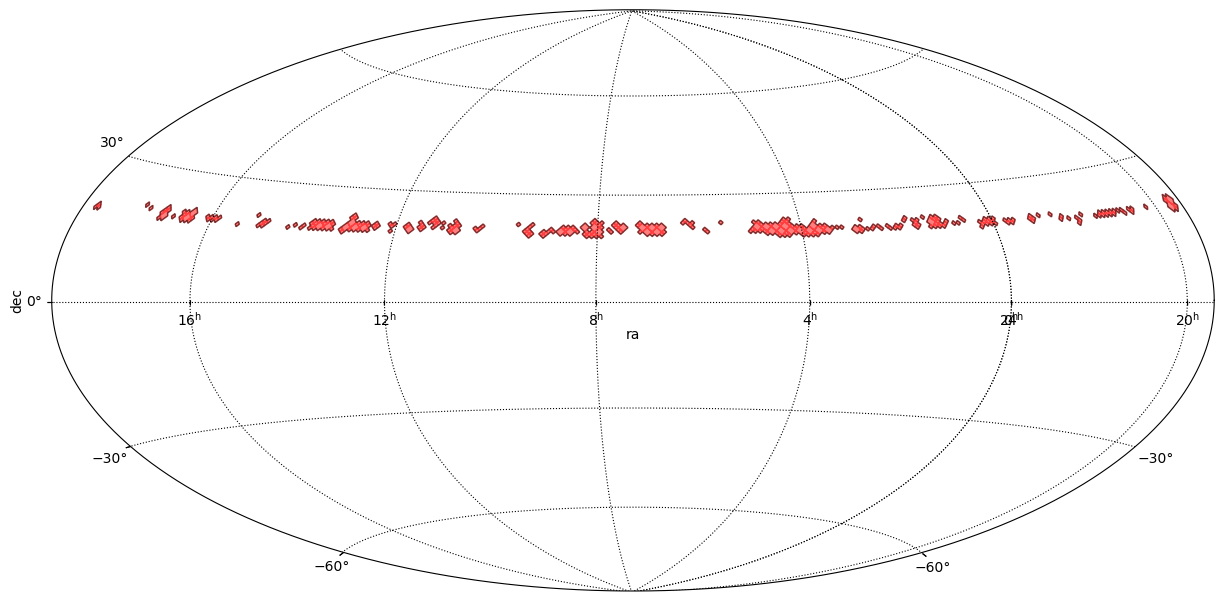

In [23]:
plot(moc_observation)

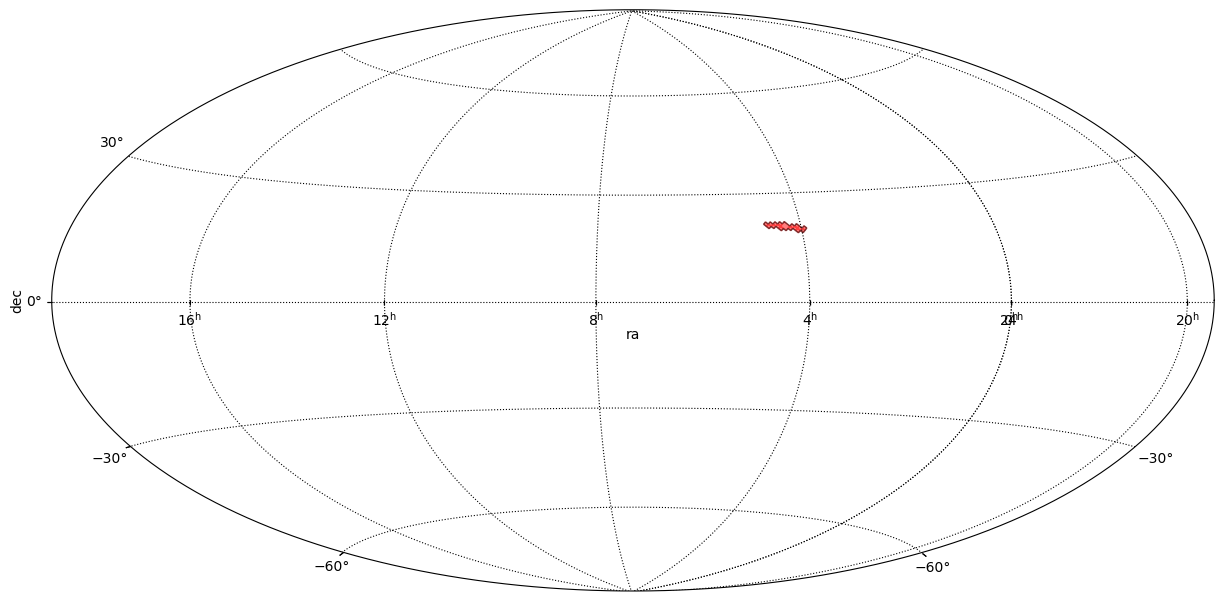

In [24]:
plot(moc_ephemcc)

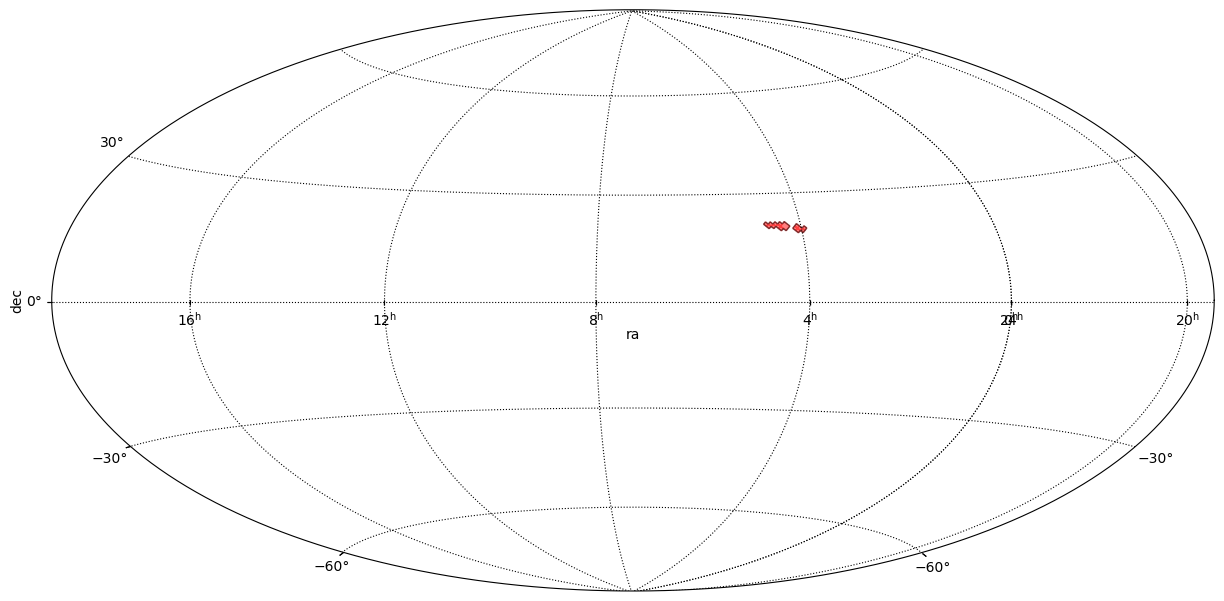

In [25]:
plot(moc_observation.intersection(moc_ephemcc))

Since the TAP query includes all observations of the time interval, we want to remove HST observations not targeting Jupiter.

Build a mask array (`True` = Jupiter is in field of view). Use the `.intersection()` method iteratively. 

In [26]:
mask = []
for row, cov in zip(obscore, spatial_coverages):
    stmoc_row = STMOC.from_spatial_coverages(
        Time(row['t_min'], format='mjd'),
        Time(row['t_max'], format='mjd'),
        cov
    )
    if stmoc_row.intersection(stmoc_ephemcc).is_empty():
        mask.append(False)
    else:
        print(row['obs_id'], row['calib_level'], row['target_name'])
        mask.append(True)

1862 2 JUPITER
1862 1 JUPITER
o65ha1010 2 JUPITER
o65ha1010 3 JUPITER
o65ha1010 1 JUPITER
o5hyb5ewq 1 JUP-NORTH-IOFOOT-55
o5hyb5eoq 2 JUP-NORTH-IOFOOT-55
o5hyb5eoq 1 JUP-NORTH-IOFOOT-55
o5hyb5ewq 2 JUP-NORTH-IOFOOT-55
o65ha1020 2 JUPITER
o65ha1020 3 JUPITER
o65ha1020 1 JUPITER
p1200304 3 JUPITER-NPOLE
p1200506 3 NAURORA-DEC31
p1200607 3 SAURORA-DEC31
p1200708 3 NAURORA-JAN13
o6baa5boq 2 JUP-NORTH2
o6baa5boq 1 JUP-NORTH2
o6ba06s0q 2 JUP-NORTH2
o6ba06s0q 1 JUP-NORTH2
o6baa5bqq 2 JUP-NORTH2
o6baa5bqq 1 JUP-NORTH2
o6ba03voq 2 JUP-NORTH
o6ba03voq 1 JUP-NORTH
o6baa1otq 2 JUP-SOUTH
o6baa1otq 1 JUP-SOUTH
o6baa6tgq 2 JUP-SOUTH2
o6baa6tgq 1 JUP-SOUTH2
o6bab7yaq 2 JUP-SOUTH2
o6bab7yaq 1 JUP-SOUTH2
o6baa7xmq 2 JUP-NORTH2
o6baa7xmq 1 JUP-NORTH2
o6bab7ycq 2 JUP-SOUTH2
o6bab7ycq 1 JUP-SOUTH2
o6ba02moq 2 JUP-NORTH
o6ba02moq 1 JUP-NORTH
o6ba02mqq 2 JUP-NORTH
o6ba02mqq 1 JUP-NORTH
o6ba03vqq 2 JUP-NORTH
o6ba03vqq 1 JUP-NORTH
o6ba03v2q 2 JUP-NORTH
o6ba03v2q 1 JUP-NORTH
o6ba03v0q 2 JUP-NORTH
o6ba03v0q 1 JU

Compute the number of unique `obs_id` (observations), list the unique values of `target_name` used by the observers.

There are 437 results, some are duplicated with different processing levels. This includes observations of close targets, most notably Jupiter satellites.